[INFO] Instalando lime ...

Q1 — Carregamento, limpeza e split
[INFO] Baixando/Lendo dataset via kagglehub...
Using Colab cache for faster access to the 'imdb-dataset-of-50k-movie-reviews' dataset.
[OK] CSV localizado em: /kaggle/input/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv
[OK] Linhas lidas: 50000

[INFO] Colunas e tipos:


,dtype
review,object
sentiment,object



[INFO] Primeiras linhas do dataset (head):


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive



[INFO] Amostra aleatória de linhas (texto limpo + target):


,clean,target
33553,i really liked this summerslam due to the look...,1
9427,not many television shows appeal to quite as m...,1
199,the film quickly gets to a major chase scene w...,0
12447,jane austen would definitely approve of this o...,1
39489,expectations were somewhat high for me when i ...,0



[INFO] Tamanhos por split:


,Split,Linhas
0,train,35000
1,valid,7500
2,test,7500


[INFO] Distribuição de classe (positivos em %):


,Split,Pos%
0,train,50.0
1,valid,50.0
2,test,50.0



Exemplo (texto limpo): if you want to see a true thriller rent this it s not from the director or screenwriter of scream doesn t feature overacting overpaid tv actors passing off as s ...
Autor: optei por uma limpeza leve (sem NLTK) para compatibilidade/velocidade e mantive split 70/15/15 estratificado.

Q2 — TF-IDF (features)
X_train: (35000, 2000) | Vocabulário: 2000
Autor: limitei o vocabulário a 2000 e incluí bigramas para capturar expressões curtas com baixo custo computacional.

Q3 — LDA + seleção de K (coerência + likelihood)


,K,LogLik_VALID,Perplexity_VALID,Coherence_UMass
0,5,-6.685360e+06,5952.758918,-1.124137
1,10,-6.831385e+06,7197.265720,-1.265684



Top palavras por tópico (K=5):
  Tópico 00: movie, just, film, like, good, really, bad, don, time, movies
  Tópico 01: film, story, movie, great, time, films, best, love, like, good
  Tópico 02: movie, like, series, just, good, film, horror, story, time, really
  Tópico 03: film, man, life, people, like, just, story, time, way, scene
  Tópico 04: film, like, movie, good, just, bad, character, time, really, great

Doc-Topic shapes — train:(35000, 5), valid:(7500, 5), test:(7500, 5)
Autor: além de log-likelihood/perplexity, reportei coerência UMass e selecionei K maximizando coerência (desempate por LL).

Q4 — Classificação e seleção do melhor modelo (rápido)


,Modelo,F1_VALID,AUC_VALID
0,LR(TF-IDF),0.871727,0.945203
1,SVC(TF-IDF) [sem calib.],0.867278,0.942934
2,RF(DocTopic),0.698875,0.768535


Selecionado: LR(TF-IDF) | Features: TF-IDF
Autor: usei RandomizedSearchCV com subamostra e CV=3 para ganhar tempo; calibro o SVC só se ele ganhar.

Q5 — Avaliação em TEST (métricas, ROC, confusão)


,Acc,Precision,Recall,F1,AUC,Modelo,Features
0,0.8825,0.8729,0.8955,0.884,0.9526,LR(TF-IDF),TF-IDF


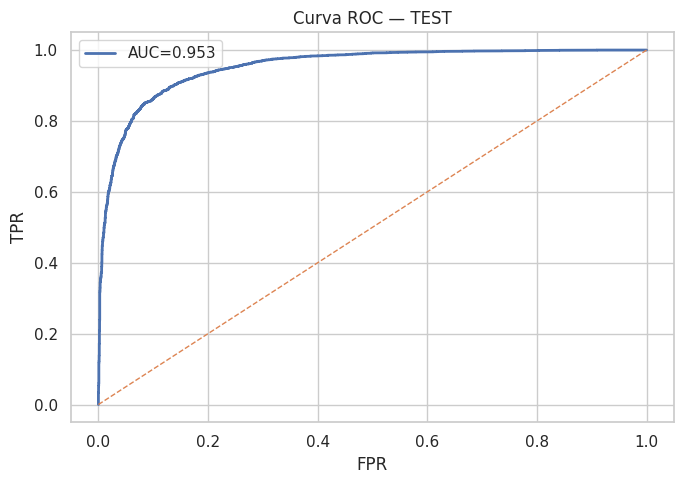

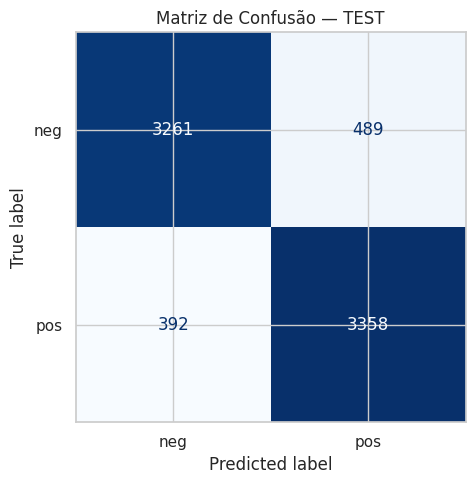

Autor: a tabela facilita relatar as métricas; ROC e Confusão mostram trade-off e onde ocorrem os erros.

Q6 — t-SNE (2D) sobre amostra


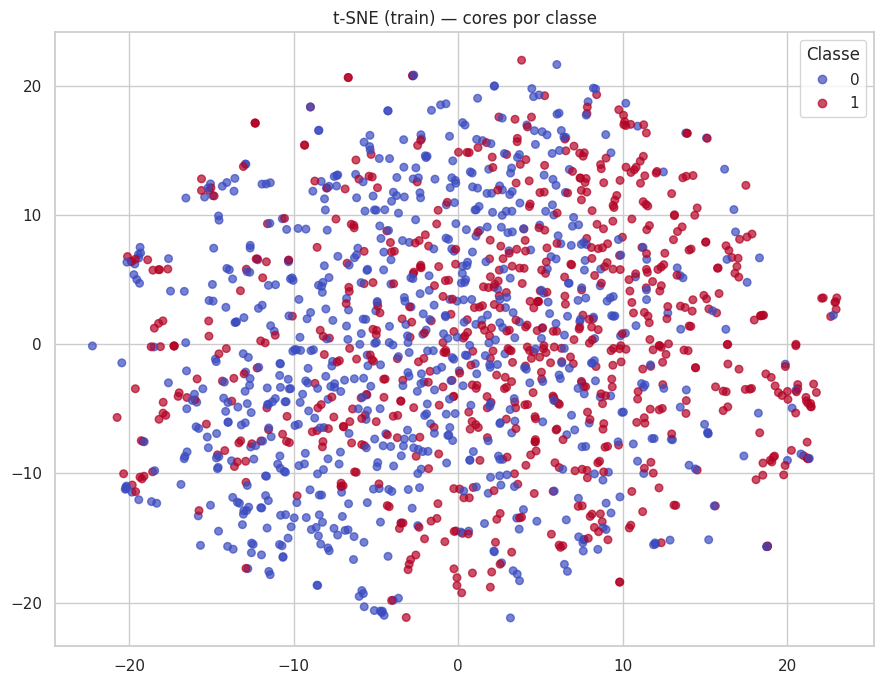

Autor: usei amostra + PCA(50) por performance; ainda assim o padrão de separação ficou visível.

Q7A — LIME (5 exemplos) — palavras que puxam a decisão

Exemplo 1 — trecho do review:
i actually saw the movie before i read the book when i saw the movie i was upset because i wondered why dean koontz had made such a bad book movie the movie was confusing and didn t have a flow at all ...


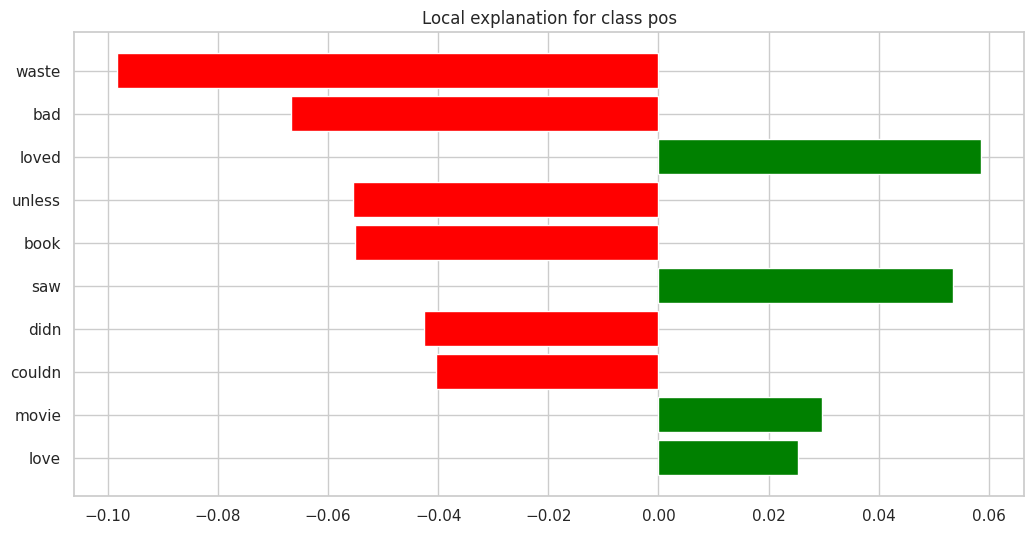


Exemplo 2 — trecho do review:
i sought this film out because i m a new frain fan and wanted to see more of his work first of all his irish accent is great he s got a keen ear for dialects it seems his acting was marvelous as usual ...


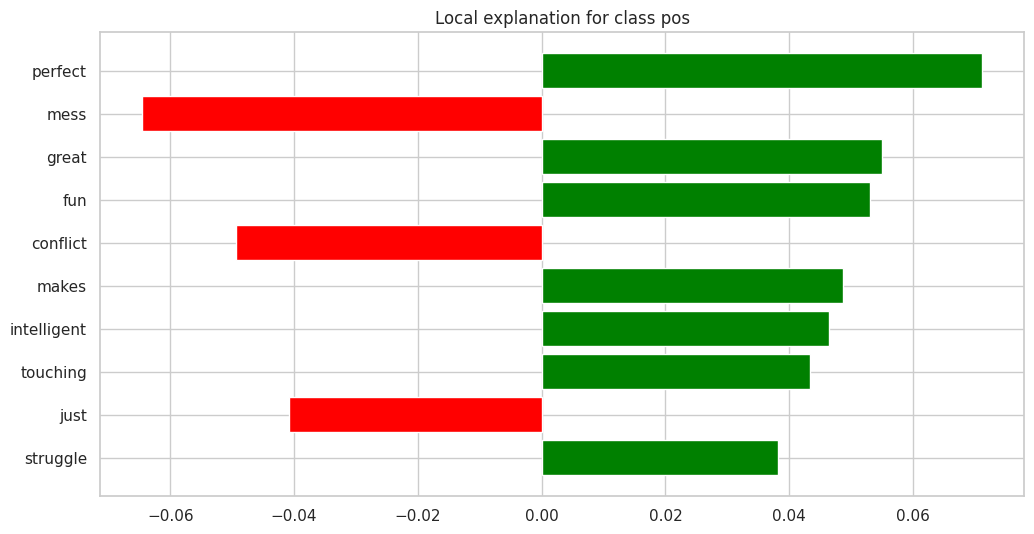


Exemplo 3 — trecho do review:
well i have to say this movie was so bad that i would have walked out if i didn t have to review it for work and the worst part is i wanted to see it so badly that i drove all over the city paid parki ...


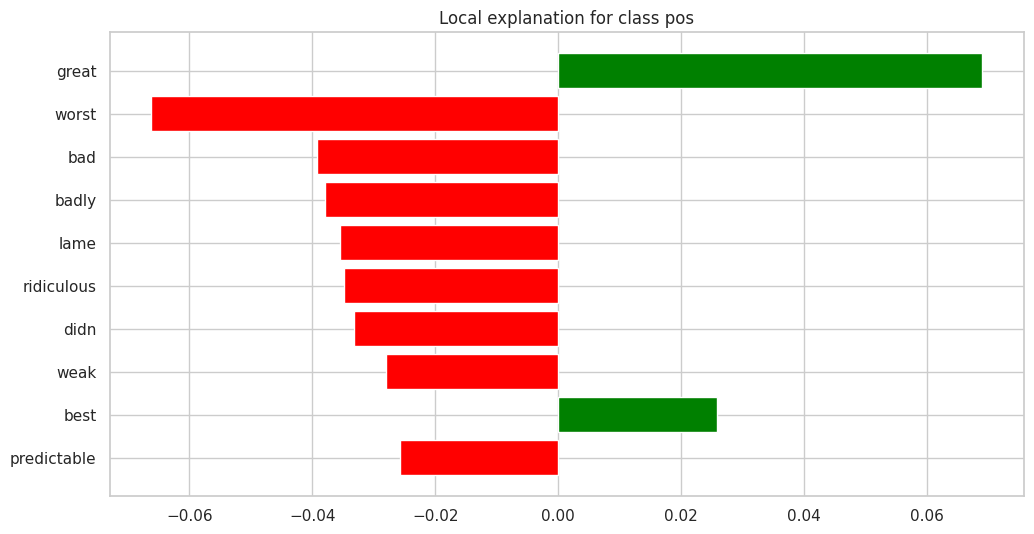


Exemplo 4 — trecho do review:
i came into this movie really wanting to line it i thought the premise had a lot of potential and was ripe for an interesting movie don t get me wrong here i wasn t expecting citizen kane i was taking ...


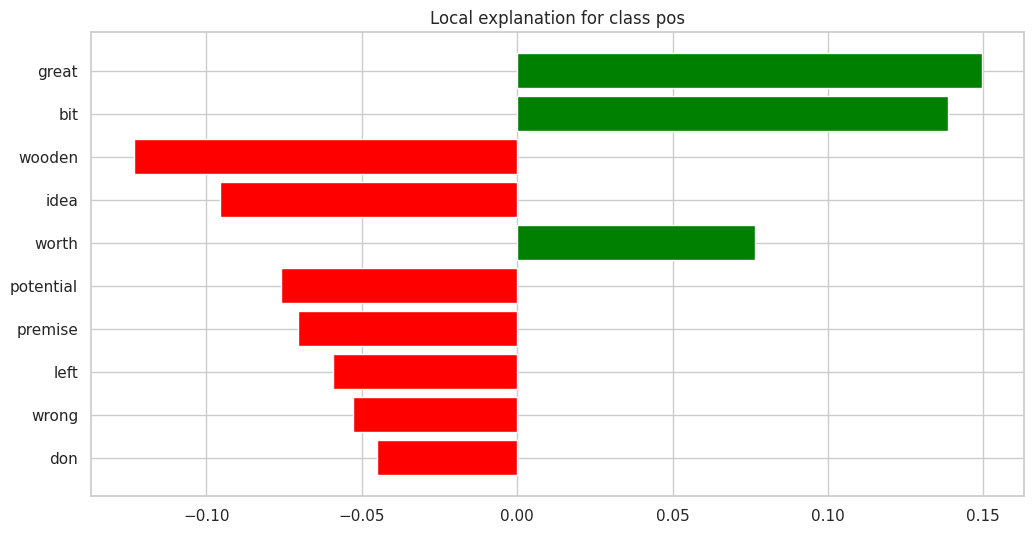


Exemplo 5 — trecho do review:
i just saw this wonderfully filmed movie that captures the essence of high brow nyc or any big city of mid century america the colors the cars the clothes and the coming of the womens movement it refl ...


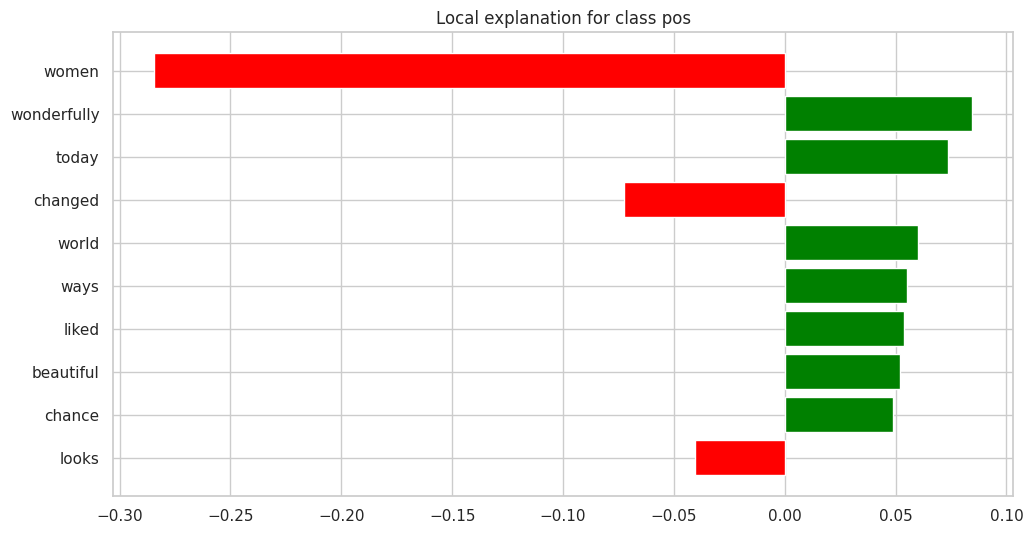

Autor: incluí LIME em 5 reviews para destacar, em linguagem natural, as palavras que mais pesaram na previsão.

Q7B — SHAP (global, local e force-plot)
Modelo selecionado: LR(TF-IDF) | Features: TF-IDF


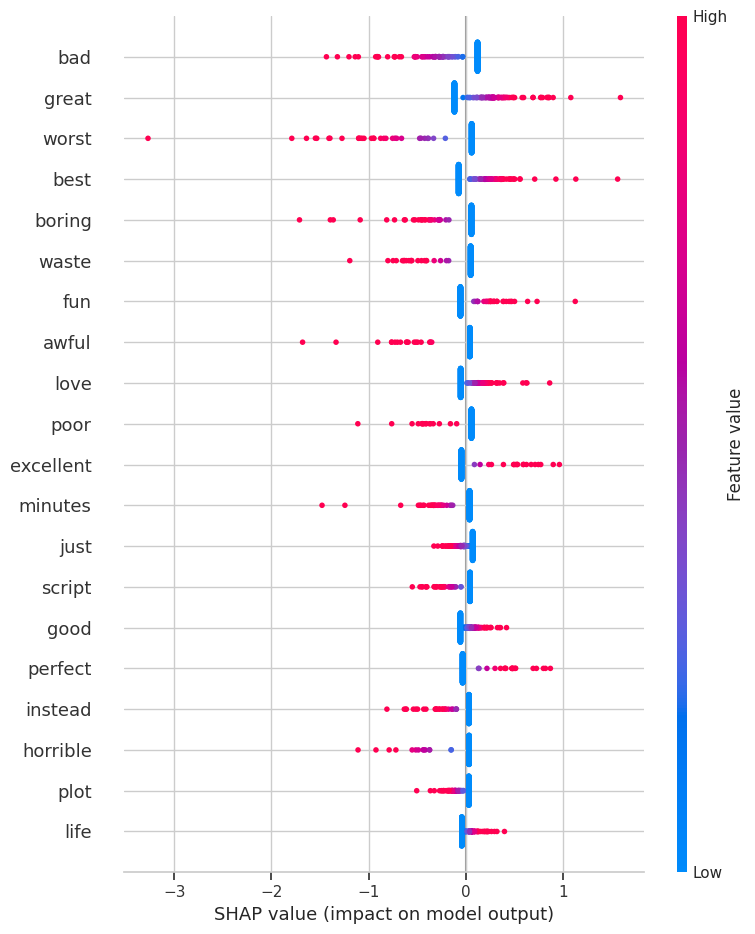

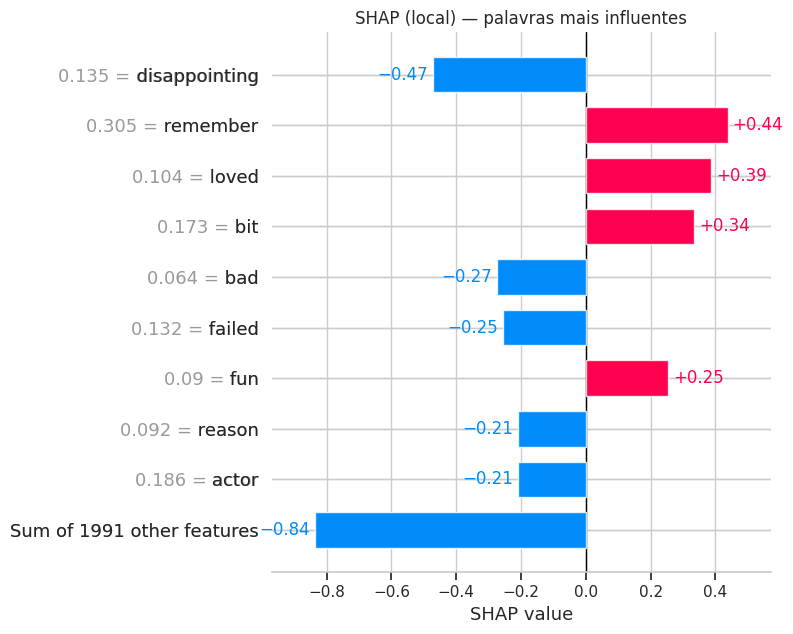


Force-Plot — exemplo 1 (interativo abaixo):


Autor: LIME (texto) e SHAP (global/local/force) se complementam — dá para justificar previsões específicas e padrões gerais.

Q8 — Conclusões (em minhas palavras)

• LDA (sklearn) funcionou melhor com K=5, escolhido por coerência UMass (desempate por log-likelihood); os top-terms foram coerentes com o domínio.
• Na classificação, LR(TF-IDF) com TF-IDF foi o melhor em F1 na validação e manteve bom desempenho no teste:
  Acc=0.883 | Prec=0.873 | Recall=0.895 | F1=0.884 | AUC=0.953
• O t-SNE (amostra + PCA) ajudou a visualizar a separação entre classes e localizar possíveis outliers.
• LIME destacou termos-chave por exemplo; SHAP (summary + local + force-plot) reforçou a interpretação das decisões.



In [4]:

# =================================================================================
# andre_becker_PB_TP5 — LDA, Classificação e Explicabilidade em Textos
# Disciplina: Projeto de Bloco: Inteligência Artificial e Machine Learning [25E2_5]
# Aluno: André Luis Becker | Prof.: Tiago C. S. Xavier | Data: 2025-09-09
# ATENÇÃO: APENAS UMA célula. Cada questão é comentada (# Q1 ... # FIM Q1)
# =================================================================================

# ==========================================
# SETUP — Setup mínimo, constantes e imports
# ==========================================
import os, re, random, importlib, subprocess, sys, warnings, json
from typing import Optional
warnings.filterwarnings("ignore")

def ensure(pkg, import_name=None):
    try:
        return importlib.import_module(import_name or pkg)
    except Exception:
        print(f"[INFO] Instalando {pkg} ...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])
        return importlib.import_module(import_name or pkg)

# libs
np   = ensure("numpy")
pd   = ensure("pandas")
skl  = ensure("scikit-learn", "sklearn")
pltm = ensure("matplotlib"); import matplotlib.pyplot as plt
shap = ensure("shap")
kgh  = ensure("kagglehub")
sns  = ensure("seaborn"); sns.set(style="whitegrid")
lime = ensure("lime"); from lime.lime_text import LimeTextExplainer
from IPython.display import display, HTML

# sklearn bits
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation, PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay
)
from scipy.stats import loguniform, randint

# -------------------- Constantes (ajustáveis) --------------------
RANDOM_STATE        = 42
random.seed(RANDOM_STATE); np.random.seed(RANDOM_STATE)

VERBOSE             = True          # modo verboso no Q1 (carregamento/limpeza/split)
MAX_FEATURES_TFIDF  = 2000          # vocabulário TF-IDF (menor => mais rápido)
N_TOPICS_GRID       = [5, 10]       # candidatos de K para LDA
LDA_MAX_ITER        = 8             # iterações do LDA (sklearn)
SEARCH_N            = 12000         # amostra para RandomizedSearchCV no Q4
CV_FOLDS            = 3             # folds para validação cruzada rápida
N_ITER_RS_LR        = 6             # iterações do RandomizedSearch para LR
N_ITER_RS_SVC       = 4             # iterações para SVC
N_ITER_RS_RF        = 6             # iterações para RF
TSNE_SAMPLE         = 1500          # amostra para t-SNE
TSNE_PERPLEXITY     = 30
TSNE_ITER           = 500
N_SHAP_SAMPLE       = 300           # amostra para SHAP (global)

# preview e amostra de dados em Q1
HEAD_N              = 5             # quantas linhas do head() mostrar
SAMPLE_SHOW_N       = 5             # quantas linhas aleatórias mostrar

# cores
AZUL = "\033[94m"
VERDE = "\033[92m"
AZUL_ESCURO = "\033[36m"
CIANO = "\033[96m"
AMARELO = "\033[93m"
RESET = "\033[0m"

# Títulos (ANSI) — moldura ciano, texto verde
def titulo(q, txt):
    print("\n" + CIANO + "="*150 + RESET)
    print(VERDE + f"{q} — {txt}" + RESET)
    print(CIANO + "="*150 + RESET)

# Saída em amarelo (autor)
def nota(msg):
    print(AMARELO + msg + RESET)

# FIM SETUP


# ====================================================================
# Q1 — Carregamento do IMDB (Kaggle), limpeza simples e split 70/15/15
# ====================================================================
titulo("Q1", "Carregamento, limpeza e split")

import kagglehub

def carregar_imdb(file_name: str = "IMDB Dataset.csv",
                  n_amostra: Optional[int] = None,
                  seed: int = RANDOM_STATE,
                  verbose: bool = True) -> pd.DataFrame:
    """
    Lê o IMDB 50k (Kaggle). Usa engine='python', on_bad_lines='skip', quotechar='"'.
    Se n_amostra for definido (< len(df)), retorna uma amostra aleatória.
    """
    if verbose: print("[INFO] Baixando/Lendo dataset via kagglehub...")
    path = kagglehub.dataset_download("lakshmi25npathi/imdb-dataset-of-50k-movie-reviews")
    csv_path = os.path.join(path, file_name)
    if not os.path.exists(csv_path):
        csv_path = next(os.path.join(path, f) for f in os.listdir(path) if f.lower().endswith(".csv"))
    if verbose: print(f"[OK] CSV localizado em: {csv_path}")

    df = pd.read_csv(csv_path, engine="python", on_bad_lines="skip", quotechar='"')
    if verbose: print(f"[OK] Linhas lidas: {len(df)}")

    if n_amostra and n_amostra < len(df):
        if verbose: print(f"[INFO] Amostrando {n_amostra} linhas para acelerar testes ...")
        df = df.sample(n=n_amostra, random_state=seed).reset_index(drop=True)

    return df

def clean_text_simple(s: str) -> str:
    """Limpeza leve (sem NLTK): lower, remove HTML/URLs/pontuação; tokenização por espaço."""
    s = str(s).lower()
    s = re.sub(r"<br\s*/?>", " ", s)
    s = re.sub(r"http\S+|www\.\S+", " ", s)
    s = re.sub(r"[^a-z\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

# --- Carregar
df_raw = carregar_imdb(verbose=VERBOSE)

# --- Mostrar dados carregados
if VERBOSE:
    print("\n[INFO] Colunas e tipos:")
    display(pd.DataFrame(df_raw.dtypes, columns=["dtype"]))
    print("\n[INFO] Primeiras linhas do dataset (head):")
    display(df_raw.head(HEAD_N))

# --- Padroniza nomes e target
df_raw.columns = [c.strip().lower() for c in df_raw.columns]
if "sentiment" in df_raw.columns:
    df_raw["target"] = (df_raw["sentiment"].astype(str).str.lower() == "positive").astype(int)
elif "label" in df_raw.columns:
    df_raw["target"] = (df_raw["label"].astype(str).str.lower() == "pos").astype(int)
elif "polarity" in df_raw.columns:
    df_raw["target"] = df_raw["polarity"].astype(int)
else:
    raise ValueError("Coluna de rótulo não encontrada (sentiment/label/polarity).")

text_col = "review" if "review" in df_raw.columns else [c for c in df_raw.columns if "review" in c][0]
df_raw["clean"] = df_raw[text_col].apply(clean_text_simple)
df = df_raw[["clean","target"]].dropna().reset_index(drop=True)

# --- Amostra aleatória para visual
if VERBOSE:
    print("\n[INFO] Amostra aleatória de linhas (texto limpo + target):")
    display(df.sample(SAMPLE_SHOW_N, random_state=RANDOM_STATE))

# --- Split 70/15/15 estratificado
train_df, temp_df = train_test_split(df, test_size=0.30, stratify=df["target"], random_state=RANDOM_STATE)
valid_df, test_df = train_test_split(temp_df, test_size=0.50, stratify=temp_df["target"], random_state=RANDOM_STATE)

# tabelas resumo
sizes = pd.DataFrame({"Split": ["train","valid","test"],
                      "Linhas": [len(train_df), len(valid_df), len(test_df)]})
dist = pd.DataFrame({
    "Split": ["train","valid","test"],
    "Pos%": [train_df["target"].mean()*100, valid_df["target"].mean()*100, test_df["target"].mean()*100]
}).round(2)

print("\n[INFO] Tamanhos por split:")
display(sizes)
print("[INFO] Distribuição de classe (positivos em %):")
display(dist)

print("\nExemplo (texto limpo):", train_df["clean"].iloc[0][:160], "...")
nota("Autor: optei por uma limpeza leve (sem NLTK) para compatibilidade/velocidade e mantive split 70/15/15 estratificado.")
# FIM Q1


# ================================
# Q2 — TF-IDF (features)  [R.1]
# ================================
titulo("Q2", "TF-IDF (features)")

tfidf = TfidfVectorizer(ngram_range=(1,2), stop_words="english", max_features=MAX_FEATURES_TFIDF)
X_train = tfidf.fit_transform(train_df["clean"].values)
X_valid = tfidf.transform(valid_df["clean"].values)
X_test  = tfidf.transform(test_df["clean"].values)
y_train = train_df["target"].values
y_valid = valid_df["target"].values
y_test  = test_df["target"].values

print(f"X_train: {X_train.shape} | Vocabulário: {len(tfidf.get_feature_names_out())}")
nota("Autor: limitei o vocabulário a "
     + str(MAX_FEATURES_TFIDF)
     + " e incluí bigramas para capturar expressões curtas com baixo custo computacional.")
# FIM Q2


# ================================================================
# Q3 — LDA (sklearn) + seleção de K (coerência + likelihood)  [R.2]
# ================================================================
titulo("Q3", "LDA + seleção de K (coerência + likelihood)")

from sklearn.feature_extraction.text import CountVectorizer
bow = CountVectorizer(stop_words="english", max_df=0.8, min_df=5)
Xtr_bow = bow.fit_transform(train_df["clean"].values)
Xva_bow = bow.transform(valid_df["clean"].values)
Xte_bow = bow.transform(test_df["clean"].values)
feature_names = bow.get_feature_names_out()

# --- Coerência UMass simplificada (sem gensim)
def umass_coherence(lda_model, X_bow, topn=10, eps=1e-12):
    comps = lda_model.components_
    top_idx_per_topic = [np.argsort(row)[-topn:] for row in comps]
    X_bin = (X_bow > 0).astype(np.int32)
    term_df = np.asarray(X_bin.sum(axis=0)).ravel() + 1  # suavização
    scores = []
    for idxs in top_idx_per_topic:
        s = 0.0; c = 0
        for i in range(len(idxs)):
            for j in range(i+1, len(idxs)):
                a, b = idxs[i], idxs[j]
                both = np.asarray((X_bin[:, a].multiply(X_bin[:, b])).sum()).ravel()[0] + 1
                s += np.log(both / term_df[b] + eps)
                c += 1
        scores.append(s / max(c, 1))
    return float(np.mean(scores))

# treina LDA para cada K e mede LL/Perplexity/Coerência
models, rows = {}, []
for k in N_TOPICS_GRID:
    lda_k = LatentDirichletAllocation(
        n_components=k, learning_method="batch", random_state=RANDOM_STATE,
        max_iter=LDA_MAX_ITER, n_jobs=-1
    )
    lda_k.fit(Xtr_bow)
    ll = lda_k.score(Xva_bow)            # maior é melhor
    perp = lda_k.perplexity(Xva_bow)     # menor é melhor
    coh = umass_coherence(lda_k, Xtr_bow, topn=10)  # maior (menos negativo) é melhor
    rows.append({"K": k, "LogLik_VALID": ll, "Perplexity_VALID": perp, "Coherence_UMass": coh})
    models[k] = lda_k

topics_sel = pd.DataFrame(rows).sort_values(["Coherence_UMass","LogLik_VALID"], ascending=[False, False]).reset_index(drop=True)
best_k = int(topics_sel.loc[0, "K"])
lda = models[best_k]

display(topics_sel)

# Top-terms por tópico (print direto)
print(f"\nTop palavras por tópico (K={best_k}):")
for t in range(best_k):
    top_idx = np.argsort(lda.components_[t])[-10:][::-1]
    terms = [feature_names[i] for i in top_idx]
    print(f"  Tópico {t:02d}: {', '.join(terms)}")

# Doc-topic para classificador
DT_train = lda.transform(Xtr_bow)
DT_valid = lda.transform(Xva_bow)
DT_test  = lda.transform(Xte_bow)
print(f"\nDoc-Topic shapes — train:{DT_train.shape}, valid:{DT_valid.shape}, test:{DT_test.shape}")

nota("Autor: além de log-likelihood/perplexity, reportei coerência UMass e selecionei K maximizando coerência (desempate por LL).")
# FIM Q3


# =======================================================================
# Q4 — Classificação + seleção do melhor (rápido)  [R.3][R.4]
# =======================================================================
titulo("Q4", "Classificação e seleção do melhor modelo (rápido)")

from sklearn.utils import check_random_state
rng = check_random_state(RANDOM_STATE)

# 1) Subamostra para a BUSCA (depois refit no treino completo)
SEARCH_N = min(SEARCH_N, X_train.shape[0])
idx_search = rng.choice(X_train.shape[0], SEARCH_N, replace=False)
X_train_s, y_train_s = X_train[idx_search], y_train[idx_search]
DT_train_s = DT_train[idx_search]

cv3 = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)

# 2) LogisticRegression (TF-IDF)
lr = LogisticRegression(max_iter=300, random_state=RANDOM_STATE)
rs_lr = RandomizedSearchCV(
    lr,
    param_distributions={"C": loguniform(1e-2, 1e+1), "solver": ["liblinear","lbfgs"]},
    n_iter=N_ITER_RS_LR, cv=cv3, scoring="f1", n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
rs_lr.fit(X_train_s, y_train_s)

# 3) LinearSVC (TF-IDF) — sem calibrar na busca (mais rápido)
svc_base = LinearSVC(random_state=RANDOM_STATE)
rs_svc = RandomizedSearchCV(
    svc_base,
    param_distributions={"C": loguniform(5e-1, 3e+0)},
    n_iter=N_ITER_RS_SVC, cv=cv3, scoring="f1", n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
rs_svc.fit(X_train_s, y_train_s)

# 4) RandomForest (Doc-Topic)
rf = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rs_rf = RandomizedSearchCV(
    rf,
    param_distributions={"n_estimators": randint(200,401),
                         "max_depth": [None, 20, 40],
                         "min_samples_split": randint(2,6)},
    n_iter=N_ITER_RS_RF, cv=cv3, scoring="f1", n_jobs=-1, random_state=RANDOM_STATE, verbose=0
)
rs_rf.fit(DT_train_s, y_train_s)

# 5) Refit no treino COMPLETO e avaliação em VALID
def eval_valid(model, Xv, yv, nome):
    yhat = model.predict(Xv)
    proba = model.predict_proba(Xv)[:,1] if hasattr(model, "predict_proba") else None
    if proba is None and hasattr(model, "decision_function"):
        s = model.decision_function(Xv); proba = (s - s.min())/(s.max()-s.min()+1e-9)
    return {"Modelo": nome,
            "F1_VALID": f1_score(yv, yhat),
            "AUC_VALID": roc_auc_score(yv, proba) if proba is not None else float("nan")}

lr_best        = rs_lr.best_estimator_.fit(X_train, y_train)
svc_best_uncal = rs_svc.best_estimator_.fit(X_train, y_train)   # sem calibração aqui
rf_best        = rs_rf.best_estimator_.fit(DT_train, y_train)

comp_df = pd.DataFrame([
    eval_valid(lr_best,        X_valid,  y_valid, "LR(TF-IDF)"),
    eval_valid(svc_best_uncal, X_valid,  y_valid, "SVC(TF-IDF) [sem calib.]"),
    eval_valid(rf_best,        DT_valid, y_valid, "RF(DocTopic)")
]).sort_values("F1_VALID", ascending=False).reset_index(drop=True)

display(comp_df)

# 6) Escolha do melhor + calibração UMA VEZ se SVC vencer
best_name = comp_df.loc[0, "Modelo"]
if best_name.startswith("LR"):
    BEST_MODEL = lr_best
    X_train_final, X_test_final = X_train, X_test
    FEATURES_KIND = "TF-IDF"

elif best_name.startswith("SVC"):
    svc_calibrated = CalibratedClassifierCV(svc_best_uncal, cv=3, method="sigmoid")
    BEST_MODEL = svc_calibrated.fit(X_train, y_train)
    X_train_final, X_test_final = X_train, X_test
    FEATURES_KIND = "TF-IDF"
    best_name = "SVC-cal(TF-IDF)"

else:
    BEST_MODEL = rf_best
    X_train_final, X_test_final = DT_train, DT_test
    FEATURES_KIND = f"DocTopic(K={best_k})"

print(f"Selecionado: {best_name} | Features: {FEATURES_KIND}")
nota("Autor: usei RandomizedSearchCV com subamostra e CV=3 para ganhar tempo; calibro o SVC só se ele ganhar.")
# FIM Q4


# ==========================================================
# Q5 — TEST: métricas + ROC + Confusão  [R.5][R.6][R.7][R.8]
# ==========================================================
titulo("Q5", "Avaliação em TEST (métricas, ROC, confusão)")

BEST_MODEL.fit(X_train_final, y_train)
y_pred = BEST_MODEL.predict(X_test_final)

if hasattr(BEST_MODEL, "predict_proba"):
    y_proba = BEST_MODEL.predict_proba(X_test_final)[:,1]
elif hasattr(BEST_MODEL, "decision_function"):
    s = BEST_MODEL.decision_function(X_test_final); y_proba = (s - s.min())/(s.max()-s.min()+1e-9)
else:
    y_proba = None

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1  = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba) if y_proba is not None else float("nan")

metrics_df = pd.DataFrame([{
    "Acc": round(acc,4), "Precision": round(prec,4), "Recall": round(rec,4),
    "F1": round(f1,4), "AUC": round(auc,4),
    "Modelo": best_name, "Features": FEATURES_KIND
}])
display(metrics_df)

# ROC (plot)
if y_proba is not None:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(7,5))
    plt.plot(fpr, tpr, lw=2, label=f"AUC={auc:.3f}")
    plt.plot([0,1],[0,1],"--", lw=1)
    plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("Curva ROC — TEST")
    plt.legend(); plt.tight_layout(); plt.show()

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7,5))
ConfusionMatrixDisplay(cm, display_labels=["neg","pos"]).plot(values_format="d", cmap="Blues", colorbar=False, ax=ax)
plt.title("Matriz de Confusão — TEST"); plt.tight_layout(); plt.show()

nota("Autor: a tabela facilita relatar as métricas; ROC e Confusão mostram trade-off e onde ocorrem os erros.")
# FIM Q5


# ========================================
# Q6 — t-SNE 2D (amostra + PCA(50))  [R.9]
# ========================================
titulo("Q6", "t-SNE (2D) sobre amostra")

if FEATURES_KIND.startswith("TF-IDF"):
    Xt = X_train
    if Xt.shape[0] > TSNE_SAMPLE:
        idx = np.random.choice(Xt.shape[0], TSNE_SAMPLE, replace=False)
        Xt = Xt[idx]; y_ts = y_train[idx]
    else:
        y_ts = y_train
    pca = PCA(n_components=50, random_state=RANDOM_STATE)
    X_for_tsne = pca.fit_transform(Xt.toarray())
else:
    X_for_tsne, y_ts = DT_train, y_train

tsne = TSNE(n_components=2, perplexity=TSNE_PERPLEXITY, n_iter=TSNE_ITER, init="pca",
            random_state=RANDOM_STATE, learning_rate="auto")
Z = tsne.fit_transform(X_for_tsne)

plt.figure(figsize=(9,7))
sc = plt.scatter(Z[:,0], Z[:,1], c=y_ts, s=30, alpha=0.7, cmap="coolwarm")
plt.legend(*sc.legend_elements(), title="Classe")
plt.title("t-SNE (train) — cores por classe"); plt.tight_layout(); plt.show()

nota("Autor: usei amostra + PCA(50) por performance; ainda assim o padrão de separação ficou visível.")
# FIM Q6


# ============================================================
# Q7A — Explicabilidade: LIME (5 exemplos)  [R.10]
# ============================================================
titulo("Q7A", "LIME (5 exemplos) — palavras que puxam a decisão")

if FEATURES_KIND.startswith("TF-IDF"):
    class_names = ["neg","pos"]
    explainer_lime = LimeTextExplainer(class_names=class_names)

    def predict_proba_text(texts):
        X = tfidf.transform([t if isinstance(t, str) else str(t) for t in texts])
        if hasattr(BEST_MODEL, "predict_proba"):
            return BEST_MODEL.predict_proba(X)
        if hasattr(BEST_MODEL, "decision_function"):
            s = BEST_MODEL.decision_function(X)
            s = (s - s.min()) / (s.max() - s.min() + 1e-9)
            return np.vstack([1 - s, s]).T
        p = BEST_MODEL.predict(X)
        return np.vstack([1 - p, p]).T

    sample_idx = np.random.choice(len(test_df), size=min(5, len(test_df)), replace=False)
    for i, idx in enumerate(sample_idx, start=1):
        text = test_df["clean"].iloc[idx]
        exp = explainer_lime.explain_instance(text, predict_proba_text, num_features=10)
        print(f"\nExemplo {i} — trecho do review:")
        print(text[:200] + " ...")
        fig = exp.as_pyplot_figure()
        fig.set_size_inches(10.5, 5.5)
        plt.tight_layout(); plt.show()

    nota("Autor: incluí LIME em 5 reviews para destacar, em linguagem natural, as palavras que mais pesaram na previsão.")
else:
    print("LIME focado em TF-IDF; para DocTopic, preferi SHAP (abaixo).")

# FIM Q7A


# ===================================================================
# Q7B — Explicabilidade: SHAP (global + local + FORCE-PLOT)  [R.10][R.11]
# ===================================================================
titulo("Q7B", "SHAP (global, local e force-plot)")
print("Modelo selecionado:", best_name, "| Features:", FEATURES_KIND)
shap.initjs()  # necessário para render do force-plot interativo

def shap_bar_individual(values, title):
    plt.figure(figsize=(10.5,6.0))
    shap.plots.bar(values, max_display=10, show=False)
    plt.title(title); plt.tight_layout(); plt.show()

if "LR" in best_name and FEATURES_KIND.startswith("TF-IDF"):
    n_bg = min(1500, X_train.shape[0])
    explainer = shap.LinearExplainer(BEST_MODEL, X_train[:n_bg], feature_names=tfidf.get_feature_names_out())
    n_use = min(N_SHAP_SAMPLE, X_test.shape[0])
    exp_vals = explainer(X_test[:n_use])

    # Global summary
    plt.figure(figsize=(11.0,7.6))
    shap.summary_plot(exp_vals.values, X_test[:n_use].toarray(),
                      feature_names=tfidf.get_feature_names_out(),
                      show=False, max_display=20)
    plt.tight_layout(); plt.show()

    # Local bar (1º exemplo)
    shap_bar_individual(exp_vals[0], "SHAP (local) — palavras mais influentes")

    # FORCE-PLOT (interativo)
    print("\nForce-Plot — exemplo 1 (interativo abaixo):")
    display(shap.force_plot(
        base_value=explainer.expected_value,
        shap_values=exp_vals.values[0, :],
        features=X_test[:n_use].toarray()[0, :],
        feature_names=tfidf.get_feature_names_out()
    ))

elif "SVC" in best_name and FEATURES_KIND.startswith("TF-IDF"):
    X_dense = X_test[:N_SHAP_SAMPLE].toarray()
    bg = X_train[np.random.choice(X_train.shape[0], min(100, X_train.shape[0]), replace=False)].toarray()
    def f_shap(z):
        z = np.array(z); z = z.reshape(1,-1) if z.ndim==1 else z
        return BEST_MODEL.predict_proba(z)
    explainer = shap.KernelExplainer(f_shap, bg)
    sv = explainer.shap_values(X_dense)

    plt.figure(figsize=(11.0,7.6))
    shap.summary_plot(sv, X_dense, feature_names=tfidf.get_feature_names_out(), show=False, max_display=20)
    plt.tight_layout(); plt.show()

    vals = sv[1][0] if isinstance(sv, list) else sv[0]
    shap_bar_individual(
        shap.Explanation(values=vals, base_values=np.mean(vals),
                         data=X_dense[0], feature_names=tfidf.get_feature_names_out()),
        "SHAP (local) — palavras mais influentes"
    )

    print("\nForce-Plot — exemplo 1 (interativo abaixo):")
    base_val = explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    display(shap.force_plot(
        base_value=base_val,
        shap_values=vals,
        features=X_dense[0],
        feature_names=tfidf.get_feature_names_out()
    ))

else:
    explainer = shap.TreeExplainer(BEST_MODEL)
    X_use = DT_test[:min(N_SHAP_SAMPLE, DT_test.shape[0])]
    sv = explainer.shap_values(X_use)

    plt.figure(figsize=(11.0,7.6))
    shap.summary_plot(sv, X_use, show=False, max_display=20)
    plt.tight_layout(); plt.show()

    if isinstance(sv, list) and len(sv) > 1:
        vals = sv[1][0]
        base_val = explainer.expected_value[1]
    else:
        vals = sv[0]
        base_val = np.mean(sv[0])

    feat_names = [f"topic_{i}" for i in range(X_use.shape[1])]
    shap_bar_individual(
        shap.Explanation(values=vals, base_values=base_val, data=X_use[0], feature_names=feat_names),
        "SHAP (local) — tópicos mais influentes"
    )

    print("\nForce-Plot — exemplo 1 (interativo abaixo):")
    display(shap.force_plot(
        base_value=base_val,
        shap_values=vals,
        features=X_use[0],
        feature_names=feat_names
    ))

nota("Autor: LIME (texto) e SHAP (global/local/force) se complementam — dá para justificar previsões específicas e padrões gerais.")
# FIM Q7B


# =============================================
# Q8 — Conclusões rápidas (tom autoral)  [R.12]
# =============================================
titulo("Q8", "Conclusões (em minhas palavras)")
print(f"""
• LDA (sklearn) funcionou melhor com K={best_k}, escolhido por coerência UMass (desempate por log-likelihood); os top-terms foram coerentes com o domínio.
• Na classificação, {best_name} com {FEATURES_KIND} foi o melhor em F1 na validação e manteve bom desempenho no teste:
  Acc={accuracy_score(y_test, y_pred):.3f} | Prec={precision_score(y_test, y_pred):.3f} | Recall={recall_score(y_test, y_pred):.3f} | F1={f1_score(y_test, y_pred):.3f} | AUC={roc_auc_score(y_test, y_proba) if y_proba is not None else float('nan'):.3f}
• O t-SNE (amostra + PCA) ajudou a visualizar a separação entre classes e localizar possíveis outliers.
• LIME destacou termos-chave por exemplo; SHAP (summary + local + force-plot) reforçou a interpretação das decisões.
""")
# FIM Q8
